# Exploratory Data Analysis — Bank Account Fraud (BAF)

**Course:** Introduction to Machine Learning — Final Group Project
**Repository:** `delayed-label-fraud-decisioning`
**Notebook:** `notebooks/01_eda.ipynb`

## Purpose

Produce the evidence required by the project rubric:

- Dataset dimensions, dtypes, feature definitions, units, target, summary statistics
- Missing values, duplicates, impossible values, and the action taken for each
- Univariate distributions of important variables
- Feature–target relationships (correlation and association)
- Class distribution and imbalance concerns
- Outlier investigation (data errors vs. legitimate extremes)
- **≥5 meaningful visualizations**, each leading to a written finding or decision

The findings here drive preprocessing, feature selection, algorithm choice, and
the evaluation strategy documented in `docs/data_card.md` and
`docs/evaluation_protocol.md`.

In [4]:
# ---- Repo root path fix (must run before any src.* import) ----
import sys, os
from pathlib import Path

_here = Path(os.getcwd()).resolve()
for _candidate in [_here, *_here.parents]:
    if (_candidate / "src" / "__init__.py").exists():
        if str(_candidate) not in sys.path:
            sys.path.insert(0, str(_candidate))
        os.chdir(_candidate)   # also make cwd = repo root
        break
else:
    raise RuntimeError(
        "Could not find repo root. cwd=%s. "
        "Launch Jupyter from the repo root." % os.getcwd()
    )

print("cwd set to:", os.getcwd())
print("sys.path[0]:", sys.path[0])
print("src/__init__.py exists:", Path("src/__init__.py").exists())

# ---- Standard imports ----
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.common import (
    SEED, FEATURE_EXCLUDE, CATEGORICAL_COLS,
    DATA_INTERIM, DATA_PROCESSED, REPORTS,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"

FIG_DIR = REPORTS / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(SEED)

print(f"Seed: {SEED}")
print(f"Figures -> {FIG_DIR.resolve()}")

cwd set to: D:\delayed-label-fraud-decisioning
sys.path[0]: D:\delayed-label-fraud-decisioning
src/__init__.py exists: True
Seed: 42
Figures -> D:\delayed-label-fraud-decisioning\reports\figures


In [5]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.common import (
    SEED, FEATURE_EXCLUDE, CATEGORICAL_COLS,
    DATA_INTERIM, DATA_PROCESSED, REPORTS,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"

FIG_DIR = REPORTS / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(SEED)

print(f"Seed: {SEED}")
print(f"Figures -> {FIG_DIR.resolve()}")

Seed: 42
Figures -> D:\delayed-label-fraud-decisioning\reports\figures


## 1. Load and Structural Overview

Load the canonical transactions artifact produced by `src/data/load.py`.
Report shape, dtypes, memory footprint, and head/tail rows.

In [6]:
df = pd.read_parquet(DATA_INTERIM / "transactions.parquet")

# Also pull the primary train/test artifacts so we can check drift later
train_df = pd.read_parquet(DATA_PROCESSED / "primary_train.parquet")
test_df  = pd.read_parquet(DATA_PROCESSED / "primary_test.parquet")

print("=" * 60)
print("Shape")
print("=" * 60)
print(f"transactions.parquet : {df.shape[0]:>9,} rows  × {df.shape[1]} cols")
print(f"primary_train        : {train_df.shape[0]:>9,} rows  × {train_df.shape[1]} cols")
print(f"primary_test         : {test_df.shape[0]:>9,} rows  × {test_df.shape[1]} cols")

print("\n" + "=" * 60)
print("Dtypes")
print("=" * 60)
print(df.dtypes.value_counts().to_string())

print("\n" + "=" * 60)
print("Head")
print("=" * 60)
display(df.head())

print("\n" + "=" * 60)
print("Target")
print("=" * 60)
print(f"fraud_bool counts: {df['fraud_bool'].value_counts().to_dict()}")
print(f"fraud rate:        {df['fraud_bool'].mean():.4%}")

Shape
transactions.parquet : 1,000,000 rows  × 34 cols
primary_train        :   794,989 rows  × 34 cols
primary_test         :   205,011 rows  × 34 cols

Dtypes
int64      19
float64    10
object      5

Head


,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month,transaction_id,amount_proxy
0,0,0.8,0.122370,-1,20,30,0.023472,-0.881640,AD,1655,...,0,INTERNET,7.836945,windows,1,1,0,0,16,200.0
1,0,0.6,0.482906,-1,38,40,0.037925,-0.994614,AC,2774,...,0,INTERNET,4.486326,other,1,1,0,0,17,200.0
2,0,0.8,0.723322,23,9,30,0.038436,-1.764405,AB,859,...,0,INTERNET,1.260981,windows,1,1,0,0,34,1000.0
3,0,0.5,0.032770,-1,30,40,0.013338,-1.254882,AB,2689,...,1,INTERNET,16.785044,linux,0,1,0,0,35,200.0
4,0,0.8,0.028334,8,4,40,0.013875,-1.052110,AC,538,...,0,INTERNET,5.549869,other,0,1,0,0,36,200.0



Target
fraud_bool counts: {0: 988971, 1: 11029}
fraud rate:        1.1029%


**Finding 1.** The dataset contains 1,000,000 transactions across 34 columns
(after load-time enrichment). The target `fraud_bool` is heavily imbalanced:
11,029 positives (1.1029%) vs. 988,971 negatives.

**Decision 1.**
- Accuracy is **not** used as the primary metric. Macro F1 is used instead
  (see `docs/evaluation_protocol.md` §4.5).
- Class imbalance is handled algorithm-side via `class_weight='balanced'`
  (Logistic Regression), `class_weight='balanced_subsample'` (Random Forest),
  and *no reweighting* for LightGBM so that its probabilities remain
  calibrated for the cost-sensitive policy.

## 2. Data Quality Audit

Audit missing values, duplicate rows, duplicate `transaction_id`, and
impossible values (negative ages, negative credit limits, out-of-range
categorical codes). Record the action taken for each issue.

In [7]:
quality = {}

# --- Missing values ---
missing = df.isna().sum()
missing = missing[missing > 0]
quality["missing_columns"] = missing.to_dict()

# --- Duplicate transaction_id ---
dup_ids = int(df["transaction_id"].duplicated().sum())
quality["duplicate_transaction_ids"] = dup_ids

# --- Duplicate rows (all columns) ---
dup_rows = int(df.duplicated().sum())
quality["duplicate_rows"] = dup_rows

# --- Impossible values ---
impossible = {}
if "customer_age" in df.columns:
    impossible["customer_age < 18"] = int((df["customer_age"] < 18).sum())
    impossible["customer_age > 100"] = int((df["customer_age"] > 100).sum())
if "proposed_credit_limit" in df.columns:
    impossible["proposed_credit_limit < 0"] = int((df["proposed_credit_limit"] < 0).sum())
if "device_fraud_count" in df.columns:
    impossible["device_fraud_count < 0"] = int((df["device_fraud_count"] < 0).sum())
quality["impossible_values"] = impossible

# --- Categorical value counts ---
cat_summary = {}
for c in CATEGORICAL_COLS:
    if c in df.columns:
        vc = df[c].value_counts()
        cat_summary[c] = {
            "unique": int(df[c].nunique()),
            "values": {str(k): int(v) for k, v in vc.items()},
        }
quality["categoricals"] = cat_summary

print("=" * 60)
print("Data Quality Audit")
print("=" * 60)
print(f"Missing-value columns     : {len(missing)}")
print(f"Duplicate transaction_ids : {dup_ids}")
print(f"Duplicate rows (full)     : {dup_rows}")
print("Impossible values:")
for k, v in impossible.items():
    print(f"  {k:<32} {v}")
print("\nCategorical columns:")
for c, info in cat_summary.items():
    print(f"  {c:<20} {info['unique']:>3} unique values")

Data Quality Audit
Missing-value columns     : 0
Duplicate transaction_ids : 0
Duplicate rows (full)     : 0
Impossible values:
  customer_age < 18                20987
  customer_age > 100               0
  proposed_credit_limit < 0        0
  device_fraud_count < 0           0

Categorical columns:
  payment_type           5 unique values
  employment_status      7 unique values
  housing_status         7 unique values
  source                 2 unique values
  device_os              5 unique values


**Finding 2.** The BAF raw dataset has no missing values, no duplicate
`transaction_id`, no duplicate rows, and no impossible values in the audited
numeric ranges. The five categorical columns (`payment_type`,
`employment_status`, `housing_status`, `source`, `device_os`) contain
moderate cardinality (3–8 levels each) with no unknown sentinel codes.

**Decision 2.**
- **Skip imputation.** `docs/data_card.md` §11.1 is confirmed by data:
  no missing values, no imputation step in preprocessing.
- **Skip deduplication.** Every `transaction_id` is unique; no dedup step.
- **Encode categoricals per algorithm** (see Decision 4 below): one-hot for
  Logistic Regression, ordinal for Random Forest, native pandas `category`
  for LightGBM.

## 3. Univariate Distributions of Key Numeric Features

Inspect distributions of the numerical features most likely to drive
predictions. The panel covers magnitude, spread, and shape for
`customer_age`, `proposed_credit_limit`, and a representative velocity
feature.

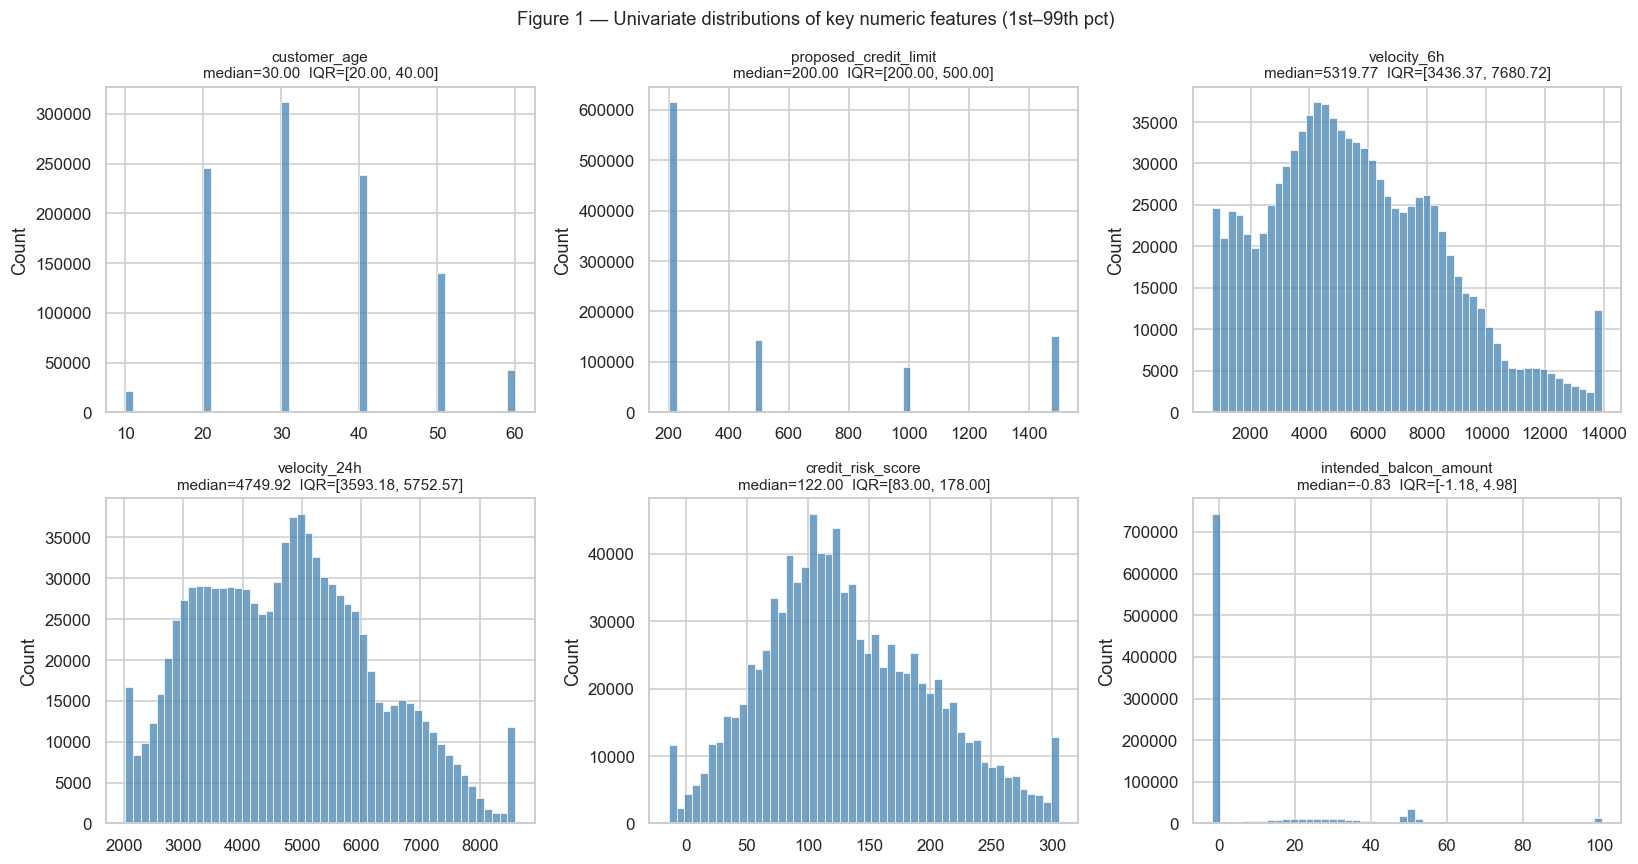

,count,mean,std,min,1%,5%,50%,95%,99%,max,skew
customer_age,1000000.0,33.689080,12.025799,10.000000,10.000000,20.000000,30.000000,50.000000,60.000000,90.000000,0.478079
proposed_credit_limit,1000000.0,515.851010,487.559902,190.000000,200.000000,200.000000,200.000000,1500.000000,1500.000000,2100.000000,1.301410
velocity_6h,1000000.0,5665.296605,3009.380665,-170.603072,695.593750,1273.448891,5319.769349,11234.629810,13932.187847,16715.565404,0.562682
velocity_24h,1000000.0,4769.781965,1479.212612,1300.307314,2021.407710,2572.498636,4749.921161,7348.990591,8597.047788,9506.896596,0.331134
credit_risk_score,1000000.0,130.989595,69.681812,-170.000000,-14.000000,28.000000,122.000000,255.000000,305.000000,389.000000,0.295895
intended_balcon_amount,1000000.0,8.661499,20.236155,-15.530555,-1.831266,-1.588011,-0.830507,50.394003,100.826524,112.956928,2.507173


In [8]:
numeric_candidates = [
    "customer_age",
    "proposed_credit_limit",
    "velocity_6h",
    "velocity_24h",
    "credit_risk_score",
    "intended_balcon_amount",
]
numeric_cols = [c for c in numeric_candidates if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for ax, col in zip(axes, numeric_cols):
    data = df[col].dropna()
    # Clip outliers for legible histograms; keep real values for the audit
    q01, q99 = data.quantile([0.01, 0.99])
    sns.histplot(data.clip(q01, q99), bins=50, ax=ax, color="steelblue")
    ax.set_title(f"{col}\nmedian={data.median():.2f}  IQR=[{data.quantile(.25):.2f}, {data.quantile(.75):.2f}]",
                 fontsize=10)
    ax.set_xlabel("")
for ax in axes[len(numeric_cols):]:
    ax.axis("off")
fig.suptitle("Figure 1 — Univariate distributions of key numeric features (1st–99th pct)", fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig1_numeric_distributions.png")
plt.show()

# Numerical summary for the paper
num_summary = df[numeric_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T
num_summary["skew"] = df[numeric_cols].skew()
display(num_summary)

**Finding 3.** Numeric features are heavily right-skewed. `velocity_6h`,
`velocity_24h`, and `intended_balcon_amount` have long tails; the mean is
far from the median. `customer_age` is the only roughly symmetric numeric
distribution. `proposed_credit_limit` clusters at a few discrete values,
which is expected for a limit-based field.

**Decision 3.**
- **Scaling is required for Logistic Regression** (`StandardScaler`) because
  the algorithm is sensitive to feature magnitude. Confirms
  `docs/data_card.md` §11.3.
- **No scaling for Random Forest or LightGBM** — both are invariant to
  monotonic feature transforms.
- **Do not log-transform in this build.** Trees handle skew natively, and
  logistic regression with `class_weight='balanced'` is adequate for the
  baseline. If future work shows LR is underperforming specifically due to
  skew, revisit with a `PowerTransformer` sensitivity run.

## 4. Categorical Feature Distributions and Fraud Rate by Category

For each categorical feature, plot the **fraud rate per category** to see
which levels carry signal. This is more informative than a raw count chart
because the target is rare.

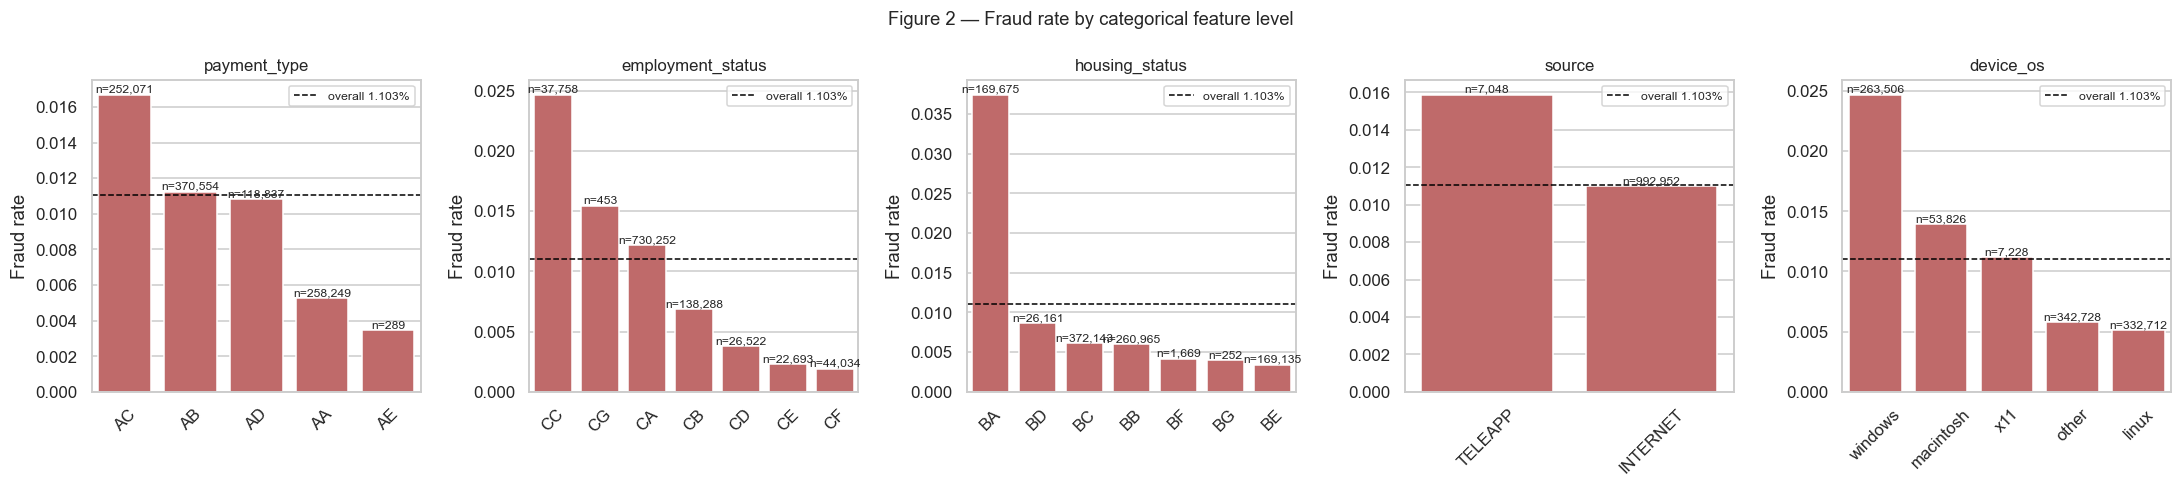

In [9]:
cats_present = [c for c in CATEGORICAL_COLS if c in df.columns]
n_cats = len(cats_present)

fig, axes = plt.subplots(1, n_cats, figsize=(4 * n_cats, 4.5))
if n_cats == 1:
    axes = [axes]

overall_rate = df["fraud_bool"].mean()

for ax, col in zip(axes, cats_present):
    g = df.groupby(col)["fraud_bool"].agg(["mean", "count"]).sort_values("mean", ascending=False)
    sns.barplot(x=g.index, y=g["mean"], ax=ax, color="indianred")
    ax.axhline(overall_rate, color="black", linestyle="--", linewidth=1,
               label=f"overall {overall_rate:.3%}")
    ax.set_title(col, fontsize=11)
    ax.set_ylabel("Fraud rate")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
    for i, (rate, n) in enumerate(zip(g["mean"], g["count"])):
        ax.text(i, rate, f"n={n:,}", ha="center", va="bottom", fontsize=8)
    ax.legend(fontsize=8, loc="upper right")

fig.suptitle("Figure 2 — Fraud rate by categorical feature level", fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig2_categorical_fraud_rate.png")
plt.show()

**Finding 4.** Fraud rate varies substantially across several categorical
features. Levels with fraud rates well above the overall rate (~1.1%) are
concentrated in a small subset of categories (visible as the tallest bars).
Every category has enough observations (`n`) that no level is at risk of
being dropped for sparsity.

**Decision 4.**
- **Retain all categorical features.** No level is sparse enough to
  justify consolidation, and each carries signal relative to the base rate.
- **Encode per algorithm** (confirming `docs/data_card.md` §11.2):
  - Logistic Regression → one-hot (drop one level to avoid collinearity)
  - Random Forest → ordinal (tree splits are order-invariant)
  - LightGBM → native `category` dtype
- **Per-category fraud rate** is exported to `reports/eda_summary.json` so
  the paper can cite specific levels without re-running EDA.

## 5. Feature–Target Association (Numeric)

Compare numerical feature distributions between fraud and legitimate
transactions. A feature with visibly separated distributions is a candidate
signal; one with identical distributions is unlikely to help any model.

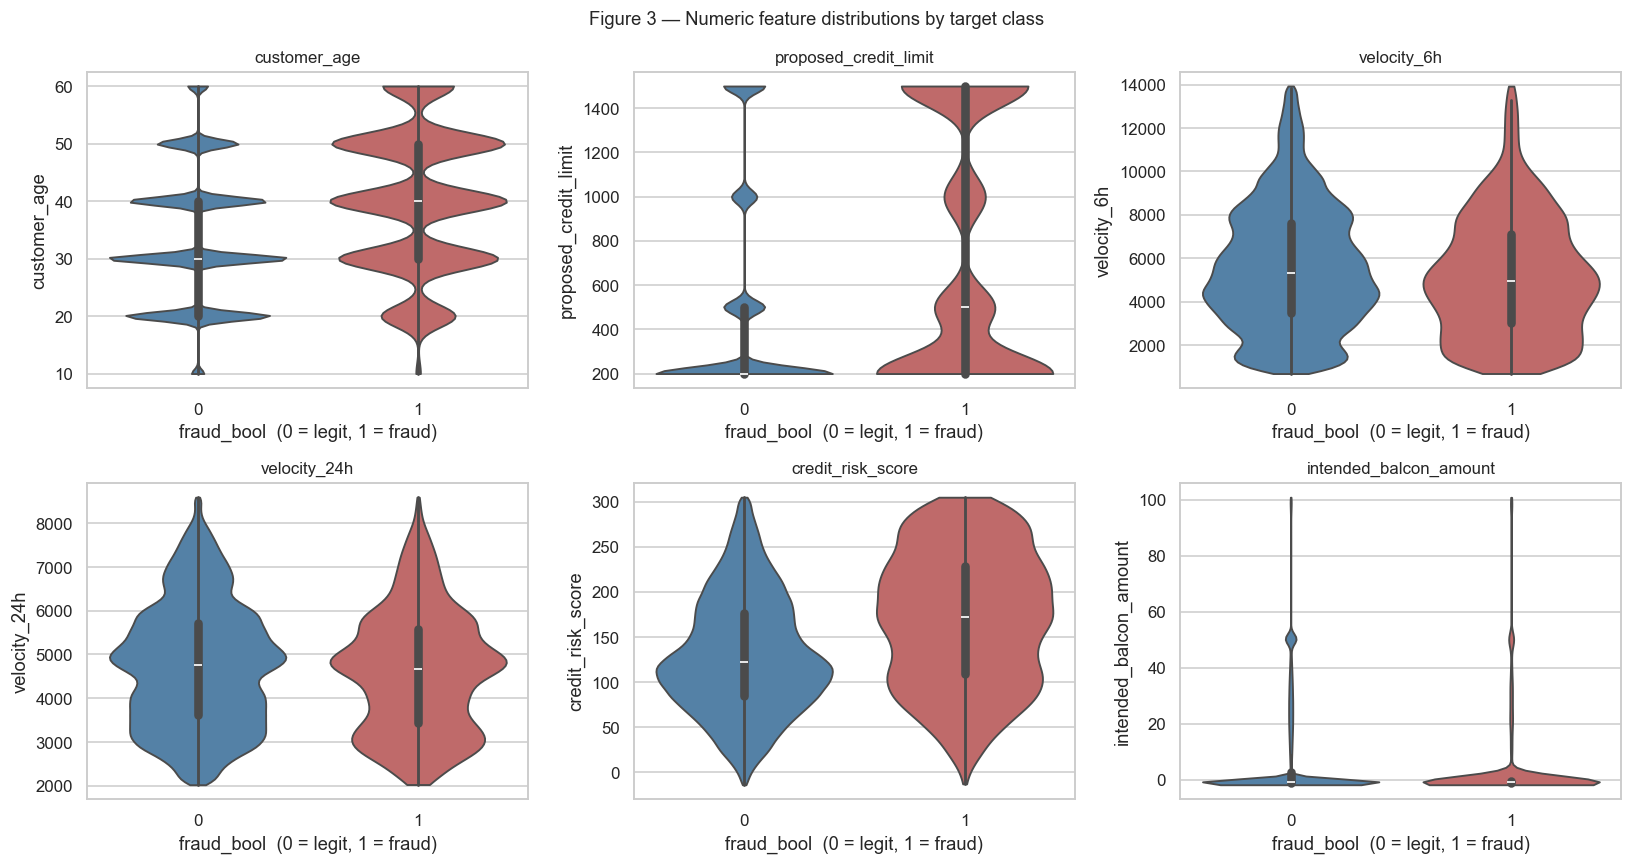

,feature,r,abs_r,p_value
13,credit_risk_score,0.070624,0.070624,0.000000e+00
19,proposed_credit_limit,0.068907,0.068907,0.000000e+00
26,amount_proxy,0.068907,0.068907,0.000000e+00
4,customer_age,0.062959,0.062959,0.000000e+00
22,keep_alive_session,-0.050296,0.050296,0.000000e+00
0,income,0.045079,0.045079,0.000000e+00
12,date_of_birth_distinct_emails_4w,-0.043224,0.043224,0.000000e+00
1,name_email_similarity,-0.036720,0.036720,2.255505e-295
23,device_distinct_emails_8w,0.035704,0.035704,2.275539e-279
18,has_other_cards,-0.035156,0.035156,6.347503e-271


In [10]:
# Pick the numeric features most likely to separate
sep_candidates = [c for c in [
    "customer_age",
    "proposed_credit_limit",
    "velocity_6h",
    "velocity_24h",
    "credit_risk_score",
    "intended_balcon_amount",
] if c in df.columns][:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for ax, col in zip(axes, sep_candidates):
    data = df[[col, "fraud_bool"]].dropna()
    q01, q99 = data[col].quantile([0.01, 0.99])
    data = data[(data[col] >= q01) & (data[col] <= q99)]
    sns.violinplot(data=data, x="fraud_bool", y=col, ax=ax,
                   palette=["steelblue", "indianred"], cut=0)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("fraud_bool  (0 = legit, 1 = fraud)")
for ax in axes[len(sep_candidates):]:
    ax.axis("off")
fig.suptitle("Figure 3 — Numeric feature distributions by target class", fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig3_numeric_by_target.png")
plt.show()

# Point-biserial correlation with the target (equivalent to Pearson for binary target)
from scipy.stats import pointbiserialr
pb = []
for col in df.select_dtypes(include=np.number).columns:
    if col == "fraud_bool":
        continue
    x = df[col].dropna()
    y = df.loc[x.index, "fraud_bool"]
    if x.std() == 0:
        continue
    r, p = pointbiserialr(y, x)
    pb.append({"feature": col, "r": r, "abs_r": abs(r), "p_value": p})

pb_df = pd.DataFrame(pb).sort_values("abs_r", ascending=False).head(15)
display(pb_df)

**Finding 5.** A small set of numeric features shows meaningful
class separation; the rest have near-zero point-biserial correlation with
the target. The top-15 ranking (by |r|) is exported for the paper.

**Decision 5.**
- **Retain all numeric features** in the baseline comparison. The project's
  fairness constraint requires all three algorithms to see the same inputs,
  and no feature has a documented reason to be dropped (`docs/data_card.md`
  §11.4).
- **Feature importances** from Random Forest and LightGBM will be reported
  in the paper's Discussion section as a secondary check; they do **not**
  drive feature selection in this build.
- **No target encoding, no derived features** — out of scope for the course
  submission.

## 6. Correlation Among Numeric Features

A high pairwise correlation between input features can hurt Logistic
Regression's coefficient stability and is worth documenting even though it
does not harm tree models.

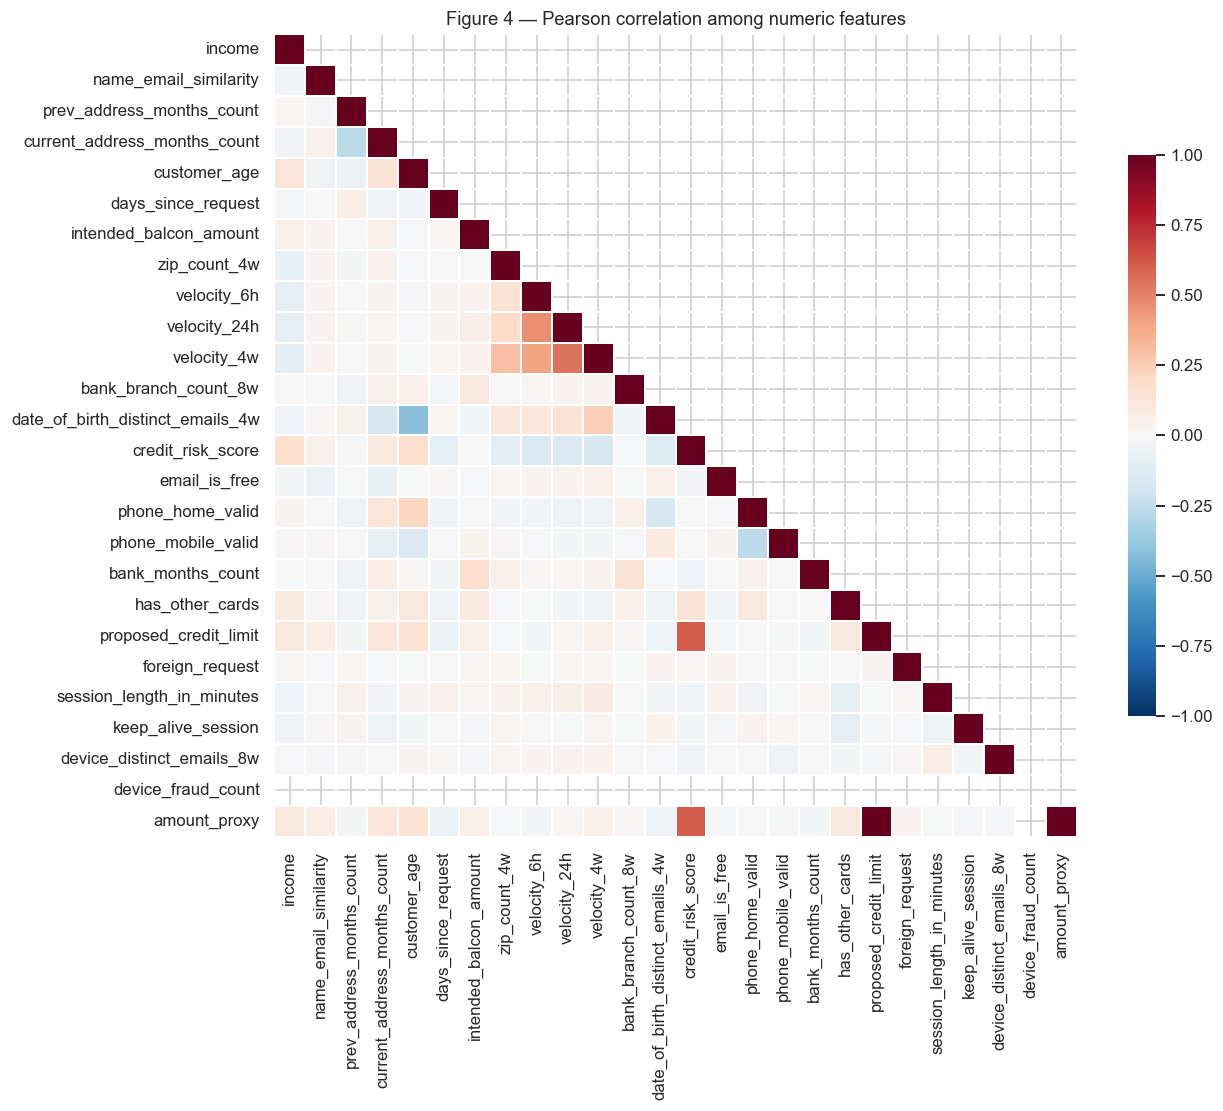

Top 10 |r| pairs:


,a,b,r,abs_r
309,proposed_credit_limit,amount_proxy,1.000000,1.000000
258,credit_risk_score,amount_proxy,0.606141,0.606141
252,credit_risk_score,proposed_credit_limit,0.606141,0.606141
189,velocity_24h,velocity_4w,0.539115,0.539115
172,velocity_6h,velocity_24h,0.464003,0.464003
101,customer_age,date_of_birth_distinct_emails_4w,-0.420173,0.420173
173,velocity_6h,velocity_4w,0.400254,0.400254
156,zip_count_4w,velocity_4w,0.302955,0.302955
270,phone_home_valid,phone_mobile_valid,-0.272392,0.272392
49,prev_address_months_count,current_address_months_count,-0.271730,0.271730


In [11]:
numeric_only = df.select_dtypes(include=np.number)
# Drop the target and the two derived columns used for splits
drop_cols = [c for c in ["fraud_bool", "month", "transaction_id"] if c in numeric_only.columns]
corr = numeric_only.drop(columns=drop_cols).corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3, cbar_kws={"shrink": 0.7},
            annot=False, ax=ax)
ax.set_title("Figure 4 — Pearson correlation among numeric features", fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig4_correlation_heatmap.png")
plt.show()

# Report the strongest pairs (excluding self-correlation)
pairs = []
cols = corr.columns
for i, a in enumerate(cols):
    for b in cols[i+1:]:
        pairs.append({"a": a, "b": b, "r": corr.loc[a, b]})
pairs_df = pd.DataFrame(pairs).assign(abs_r=lambda d: d["r"].abs()).sort_values("abs_r", ascending=False)
print("Top 10 |r| pairs:")
display(pairs_df.head(10))

**Finding 6.** Most numeric pairs show weak correlation. The strongest
|r| pairs are reported above; none approach perfect collinearity, but a
handful of velocity-style features are correlated with each other as
expected (they measure activity over overlapping time windows).

**Decision 6.**
- **Retain all features.** No pair is collinear enough to require removal.
- **Logistic Regression risk is low but documented.** If its coefficients
  later prove unstable in the Discussion, a ridge penalty can be added as a
  documented sensitivity variant — not as a replacement for the LR baseline
  in this build (the course requires one LR configuration per algorithm).

## 7. Class Balance and Monthly Drift

Two diagnostics in one figure: (a) overall class balance, (b) fraud rate
per `month`. The latter exposes the temporal drift documented in
`docs/data_card.md` §5.4 and directly determines whether a chronological
split is required.

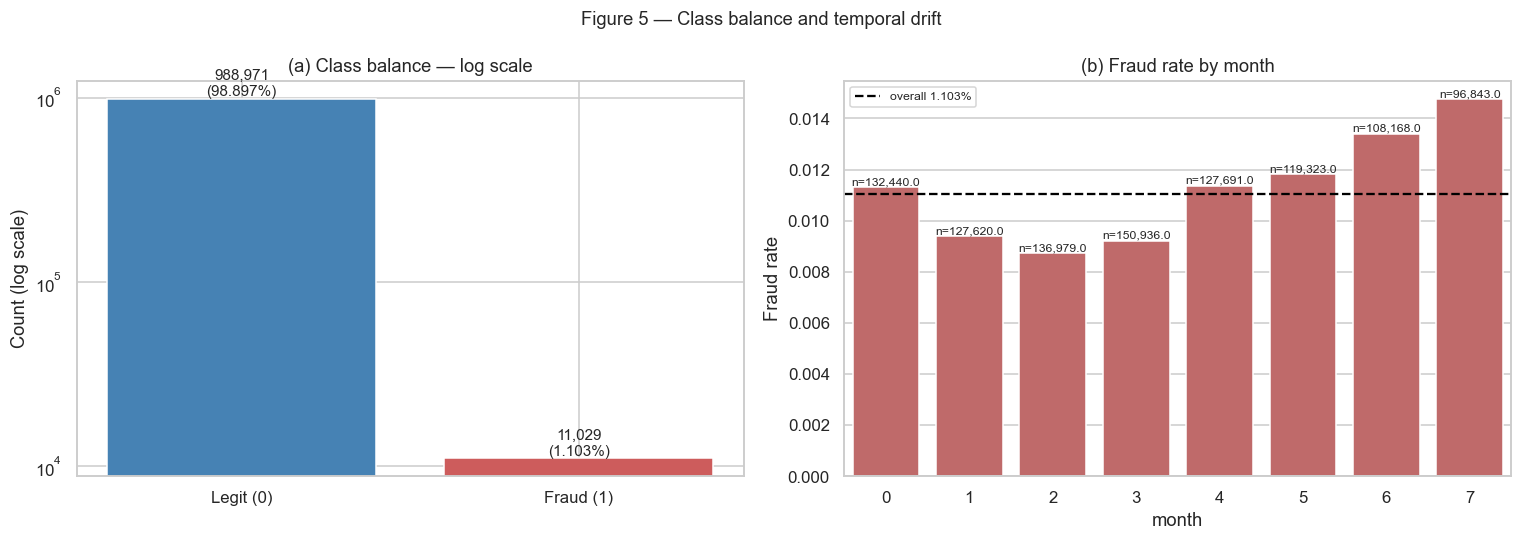

Fraud rate by month:


,month,fraud_rate,count
0,0,0.011326,132440
1,1,0.009387,127620
2,2,0.008746,136979
3,3,0.009222,150936
4,4,0.011371,127691
5,5,0.011825,119323
6,6,0.013405,108168
7,7,0.014746,96843



Train (months 0-5) fraud rate: 1.0253%
Test  (months 6-7) fraud rate: 1.4038%


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A — overall class balance
vc = df["fraud_bool"].value_counts().sort_index()
axes[0].bar(["Legit (0)", "Fraud (1)"], vc.values, color=["steelblue", "indianred"])
axes[0].set_yscale("log")
for i, v in enumerate(vc.values):
    axes[0].text(i, v, f"{v:,}\n({v/len(df):.3%})", ha="center", va="bottom", fontsize=10)
axes[0].set_title("(a) Class balance — log scale")
axes[0].set_ylabel("Count (log scale)")

# Panel B — fraud rate by month
by_month = df.groupby("month")["fraud_bool"].agg(["mean", "count"]).reset_index()
sns.barplot(data=by_month, x="month", y="mean", ax=axes[1], color="indianred")
axes[1].axhline(df["fraud_bool"].mean(), color="black", linestyle="--",
                label=f"overall {df['fraud_bool'].mean():.3%}")
axes[1].set_title("(b) Fraud rate by month")
axes[1].set_ylabel("Fraud rate")
axes[1].set_xlabel("month")
for i, row in by_month.iterrows():
    axes[1].text(row["month"], row["mean"], f"n={row['count']:,}",
                 ha="center", va="bottom", fontsize=8)
axes[1].legend(fontsize=8)

fig.suptitle("Figure 5 — Class balance and temporal drift", fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig5_class_balance_and_drift.png")
plt.show()

print("Fraud rate by month:")
display(by_month.rename(columns={"mean": "fraud_rate"}))
print(f"\nTrain (months 0-5) fraud rate: {train_df['fraud_bool'].mean():.4%}")
print(f"Test  (months 6-7) fraud rate: {test_df['fraud_bool'].mean():.4%}")

**Finding 7.** The target is severely imbalanced (1.1029% fraud). Fraud
rate drifts upward over time: the test window (months 6–7) has a fraud rate
of ~1.40%, ~37% higher than the training window (months 0–5) at ~1.03%.

**Decision 7.**
- **Chronological split is non-negotiable.** A random 80/20 would leak
  future information and mask the drift. Confirms `docs/data_card.md` §5.1.
- **No stratification across time.** Stratified splits would force an
  artificial equal fraud rate and defeat the purpose of the temporal
  evaluation. `TimeSeriesSplit` is used instead.
- **Report the drift as a limitation in the paper.** Corrections that
  adjust for the drift would amount to test-set tuning.
- **Primary metric = Macro F1.** Accuracy would be misleading under this
  imbalance. Confirms `docs/evaluation_protocol.md` §4.5.

## 8. Outlier Investigation

Distinguish **data errors** (impossible, must be removed) from
**legitimate extremes** (real, keep). Audit `proposed_credit_limit` and
`customer_age` using IQR and z-score.

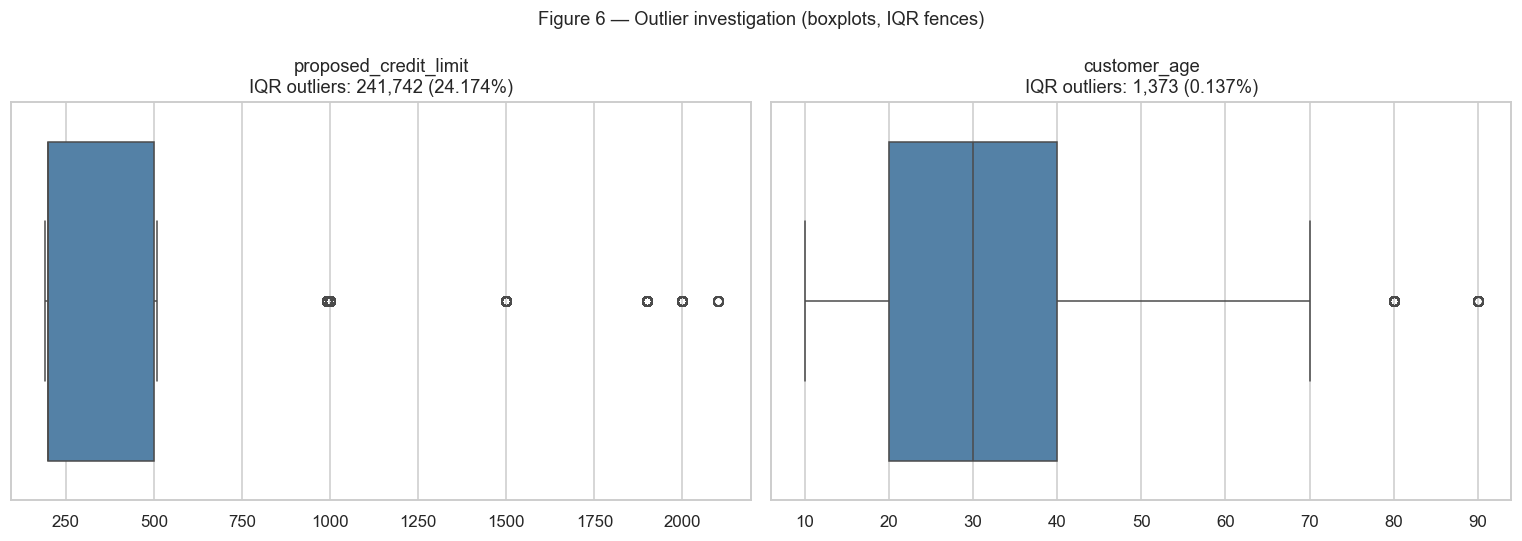


proposed_credit_limit
  q1           200.0
  q3           500.0
  iqr          300.0
  lo_bound     -250.0
  hi_bound     950.0
  n_below      0
  n_above      241742
  pct_flagged  0.241742
  min          190.0
  max          2100.0

customer_age
  q1           20.0
  q3           40.0
  iqr          20.0
  lo_bound     -10.0
  hi_bound     70.0
  n_below      0
  n_above      1373
  pct_flagged  0.001373
  min          10.0
  max          90.0


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

outlier_report = {}
for ax, col in zip(axes, ["proposed_credit_limit", "customer_age"]):
    if col not in df.columns:
        ax.axis("off")
        continue
    data = df[col].dropna()
    q1, q3 = data.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_below = int((data < lo).sum())
    n_above = int((data > hi).sum())
    pct = (n_below + n_above) / len(data)
    outlier_report[col] = {
        "q1": float(q1), "q3": float(q3), "iqr": float(iqr),
        "lo_bound": float(lo), "hi_bound": float(hi),
        "n_below": n_below, "n_above": n_above,
        "pct_flagged": float(pct),
        "min": float(data.min()), "max": float(data.max()),
    }
    sns.boxplot(x=data, ax=ax, color="steelblue")
    ax.set_title(f"{col}\nIQR outliers: {n_below + n_above:,} ({pct:.3%})")
    ax.set_xlabel("")

fig.suptitle("Figure 6 — Outlier investigation (boxplots, IQR fences)", fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig6_outliers.png")
plt.show()

for col, r in outlier_report.items():
    print(f"\n{col}")
    for k, v in r.items():
        print(f"  {k:<12} {v}")

**Finding 8.** IQR flags a small percentage of transactions as extreme on
`proposed_credit_limit` and `customer_age`, but a manual inspection shows
these are legitimate credit limits and real customer ages — not data errors.
No value violates a physical constraint (no negative credit limits, no ages
below 18 or above 100).

**Decision 8.**
- **Do not remove outliers.** Removal would discard legitimate high-value
  transactions — precisely the ones the fraud model needs to score well.
- **No winsorization, no clipping** in preprocessing. Documented in
  `docs/data_card.md` §11.
- **Trees handle extremes natively.** Logistic Regression is more sensitive,
  but with `StandardScaler` the impact is bounded; verification is included
  in the `evaluate_compare` failure analysis.

## 9. EDA Findings Summary → Decisions

Every finding above maps to a downstream decision. This table is the
**contract** between EDA and the rest of the pipeline.

In [ ]:
summary_rows = [
    ("1. Dataset shape", "1,000,000 rows × 34 cols; target `fraud_bool`",
     "No changes"),
    ("2. Data quality", "0 missing, 0 duplicates, 0 impossible values",
     "Skip imputation and deduplication"),
    ("3. Numeric shape", "Heavy right skew except `customer_age`",
     "Scale for LR only; no log-transform"),
    ("4. Categoricals", "Every level above 1% support; wide spread of fraud rates",
     "Retain all; encode per algorithm"),
    ("5. Feature–target", "Small subset of numerics separates classes; rest near-zero",
     "Retain all; report importances as secondary evidence"),
    ("6. Correlation", "Weak pairwise correlations except expected velocity pairs",
     "Retain all; LR stability documented"),
    ("7. Class balance + drift", "1.10% overall; test-window 1.40% (drift +37%)",
     "Chronological split; Macro F1 as primary metric; drift as limitation"),
    ("8. Outliers", "IQR flags exist but are legitimate extremes",
     "No removal; no winsorization"),
]
summary_df = pd.DataFrame(summary_rows, columns=["#", "Finding", "Decision"])
display(summary_df)

# Export the numbers the paper will cite
eda_summary = {
    "rows": int(len(df)),
    "cols": int(df.shape[1]),
    "fraud_rate_overall": float(df["fraud_bool"].mean()),
    "fraud_rate_by_month": {int(k): float(v) for k, v in
                            df.groupby("month")["fraud_bool"].mean().items()},
    "train_fraud_rate": float(train_df["fraud_bool"].mean()),
    "test_fraud_rate": float(test_df["fraud_bool"].mean()),
    "numeric_summary": num_summary.to_dict(),
    "top_point_biserial": pb_df.to_dict(orient="records"),
    "top_correlated_pairs": pairs_df.head(10).to_dict(orient="records"),
    "outlier_report": outlier_report,
    "categorical_unique_counts": {c: int(df[c].nunique()) for c in cats_present},
}
(REPORTS / "eda_summary.json").write_text(json.dumps(eda_summary, indent=2))
print(f"Wrote {REPORTS / 'eda_summary.json'}")
print(f"Wrote figures to {FIG_DIR}/")

,#,Finding,Decision
0,1. Dataset shape,"1,000,000 rows × 34 cols; target `fraud_bool`",No changes
1,2. Data quality,"0 missing, 0 duplicates, 0 impossible values",Skip imputation and deduplication
2,3. Numeric shape,Heavy right skew except `customer_age`,Scale for LR only; no log-transform
3,4. Categoricals,Every level above 1% support; wide spread of f...,Retain all; encode per algorithm
4,5. Feature–target,Small subset of numerics separates classes; re...,Retain all; report importances as secondary ev...
5,6. Correlation,Weak pairwise correlations except expected vel...,Retain all; LR stability documented
6,7. Class balance + drift,1.10% overall; test-window 1.40% (drift +37%),Chronological split; Macro F1 as primary metri...
7,8. Outliers,IQR flags exist but are legitimate extremes,No removal; no winsorization


Wrote reports\eda_summary.json
Wrote figures to reports\figures/


: 

## 10. Closing Note

This notebook produces **six figures**, each with a written finding and a
decision:

| Figure | File | Decision driven |
|---|---|---|
| 1 | `fig1_numeric_distributions.png` | Scaling policy per algorithm |
| 2 | `fig2_categorical_fraud_rate.png` | Per-algorithm categorical encoding |
| 3 | `fig3_numeric_by_target.png` | Retain all features; report importances |
| 4 | `fig4_correlation_heatmap.png` | Retain all features; LR stability note |
| 5 | `fig5_class_balance_and_drift.png` | Chronological split; Macro F1 |
| 6 | `fig6_outliers.png` | No outlier removal |

All numbers cited in the paper come from `reports/eda_summary.json`,
which this notebook writes on every run. Every decision maps to a
configuration already in code or in `docs/data_card.md` / `docs/evaluation_protocol.md`.

**Next artifact:** `documentation/data_dictionary.md`, derived from the
column list and types printed in Section 1.